# improving employee retention by predicting employee attrition using machine learning

## Data Preprocessing

In [1]:
import pandas as pd
import numpy as np

# 1. Load Data
df = pd.read_excel('Improving Employee Retention by Predicting Employee Attrition Using Machine Learning.xlsx')

print("--- Info Awal Dataset ---")
print(df.info())

--- Info Awal Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287 entries, 0 to 286
Data columns (total 25 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Username                            287 non-null    object 
 1   EnterpriseID                        287 non-null    int64  
 2   StatusPernikahan                    287 non-null    object 
 3   JenisKelamin                        287 non-null    object 
 4   StatusKepegawaian                   287 non-null    object 
 5   Pekerjaan                           287 non-null    object 
 6   JenjangKarir                        287 non-null    object 
 7   PerformancePegawai                  287 non-null    object 
 8   AsalDaerah                          287 non-null    object 
 9   HiringPlatform                      287 non-null    object 
 10  SkorSurveyEngagement                287 non-null    int64  
 11  SkorKepuasanPegawai

In [2]:
df.head()

,Username,EnterpriseID,StatusPernikahan,JenisKelamin,StatusKepegawaian,Pekerjaan,JenjangKarir,PerformancePegawai,AsalDaerah,HiringPlatform,...,NomorHP,Email,TingkatPendidikan,PernahBekerja,IkutProgramLOP,AlasanResign,TanggalLahir,TanggalHiring,TanggalPenilaianKaryawan,TanggalResign
0,spiritedPorpoise3,111065,Belum_menikah,Pria,Outsource,Software Engineer (Back End),Freshgraduate_program,Sangat_bagus,Jakarta Timur,Employee_Referral,...,+6282232522xxx,spiritedPorpoise3135@yahoo.com,Magister,1,1.0,masih_bekerja,1972-07-01,2011-01-10,2016-2-15,-
1,jealousGelding2,106080,Belum_menikah,Pria,FullTime,Data Analyst,Freshgraduate_program,Sangat_kurang,Jakarta Utara,Website,...,+6281270745xxx,jealousGelding2239@yahoo.com,Sarjana,1,1.0,toxic_culture,1984-04-26,2014-01-06,2020-1-17,2018-6-16
2,pluckyMuesli3,106452,Menikah,Pria,FullTime,Software Engineer (Front End),Freshgraduate_program,Bagus,Jakarta Timur,Indeed,...,+6281346215xxx,pluckyMuesli3961@icloud.com,Magister,1,1.0,jam_kerja,1974-01-07,2011-01-10,2016-01-10,2014-9-24
3,stressedTruffle1,106325,Belum_menikah,Pria,Outsource,Software Engineer (Front End),Freshgraduate_program,Bagus,Jakarta Pusat,LinkedIn,...,+6283233846xxx,stressedTruffle1406@hotmail.com,Sarjana,1,0.0,masih_bekerja,1979-11-24,2014-2-17,2020-02-04,-
4,shyTermite7,111171,Belum_menikah,Wanita,FullTime,Product Manager,Freshgraduate_program,Bagus,Jakarta Timur,LinkedIn,...,+6287883263xxx,shyTermite7149@gmail.com,Sarjana,1,0.0,ganti_karir,1974-11-07,2013-11-11,2020-1-22,2018-09-06


### Mengatasi Data null

In [3]:
df.isnull().sum()

Username                                0
EnterpriseID                            0
StatusPernikahan                        0
JenisKelamin                            0
StatusKepegawaian                       0
Pekerjaan                               0
JenjangKarir                            0
PerformancePegawai                      0
AsalDaerah                              0
HiringPlatform                          0
SkorSurveyEngagement                    0
SkorKepuasanPegawai                     5
JumlahKeikutsertaanProjek               3
JumlahKeterlambatanSebulanTerakhir      1
JumlahKetidakhadiran                    6
NomorHP                                 0
Email                                   0
TingkatPendidikan                       0
PernahBekerja                           0
IkutProgramLOP                        258
AlasanResign                           66
TanggalLahir                            0
TanggalHiring                           0
TanggalPenilaianKaryawan          

In [4]:
# a. Mengisi 'AlasanResign' yang kosong dengan label 'Masih_Bekerja'
if 'AlasanResign' in df.columns:
    df['AlasanResign'] = df['AlasanResign'].fillna('Masih_Bekerja')

# b. Mengisi kolom numerik lain dengan Median (lebih aman daripada Mean untuk data skewed)
#    Kita gunakan loop untuk mendeteksi kolom numerik yang masih ada null
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Mengisi null pada kolom '{col}' dengan median: {median_val}")

Mengisi null pada kolom 'SkorKepuasanPegawai' dengan median: 4.0
Mengisi null pada kolom 'JumlahKeikutsertaanProjek' dengan median: 0.0
Mengisi null pada kolom 'JumlahKeterlambatanSebulanTerakhir' dengan median: 0.0
Mengisi null pada kolom 'JumlahKetidakhadiran' dengan median: 10.0
Mengisi null pada kolom 'IkutProgramLOP' dengan median: 1.0


In [5]:
df.isnull().sum()

Username                              0
EnterpriseID                          0
StatusPernikahan                      0
JenisKelamin                          0
StatusKepegawaian                     0
Pekerjaan                             0
JenjangKarir                          0
PerformancePegawai                    0
AsalDaerah                            0
HiringPlatform                        0
SkorSurveyEngagement                  0
SkorKepuasanPegawai                   0
JumlahKeikutsertaanProjek             0
JumlahKeterlambatanSebulanTerakhir    0
JumlahKetidakhadiran                  0
NomorHP                               0
Email                                 0
TingkatPendidikan                     0
PernahBekerja                         0
IkutProgramLOP                        0
AlasanResign                          0
TanggalLahir                          0
TanggalHiring                         0
TanggalPenilaianKaryawan              0
TanggalResign                         0


### Inconsistence Data

In [6]:
# Target: Kolom 'PernahBekerja'
# Masalah umum: Isinya bercampur antara 'Yes'/'No' dengan '1'/'0', atau format string/integer.
# Solusi: Kita standarisasi menjadi '1' (Pernah) dan '0' (Tidak Pernah).

In [7]:
df['PernahBekerja'].unique()

array([1, 'yes'], dtype=object)

In [8]:
# Mapping standardisasi (sesuaikan jika ada variasi lain seperti 'Ya'/'Tidak')
mapping_pernah_bekerja = {'Yes': 1, 'No': 0, 'Ya': 1, 'Tidak': 0}
df['PernahBekerja'] = df['PernahBekerja'].replace(mapping_pernah_bekerja)

# Pastikan tipe datanya integer agar konsisten
df['PernahBekerja'] = pd.to_numeric(df['PernahBekerja'], errors='coerce').fillna(0).astype(int)

print("Value unik 'PernahBekerja' setelah cleaning:", df['PernahBekerja'].unique())

Value unik 'PernahBekerja' setelah cleaning: [1 0]


### Constant Columns

In [9]:
# Analisis: Kolom yang hanya memiliki 1 nilai unik (konstanta) tidak memberikan
# informasi apa-apa (variance = 0) bagi model Machine Learning.

In [10]:
# Mencari kolom dengan nunique == 1
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
print(f"\nKolom konstanta yang akan dibuang: {constant_cols}")

# Membuang kolom tersebut
df_clean = df.drop(columns=constant_cols)

print("\n--- Info Dataset Setelah Cleaning ---")
print(df_clean.info())


Kolom konstanta yang akan dibuang: []

--- Info Dataset Setelah Cleaning ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287 entries, 0 to 286
Data columns (total 25 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Username                            287 non-null    object 
 1   EnterpriseID                        287 non-null    int64  
 2   StatusPernikahan                    287 non-null    object 
 3   JenisKelamin                        287 non-null    object 
 4   StatusKepegawaian                   287 non-null    object 
 5   Pekerjaan                           287 non-null    object 
 6   JenjangKarir                        287 non-null    object 
 7   PerformancePegawai                  287 non-null    object 
 8   AsalDaerah                          287 non-null    object 
 9   HiringPlatform                      287 non-null    object 
 10  SkorSurveyEngagement            

## Annual Report on Employee Number Changes

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

### Data Preperation (Date Conversion & Extraction)

In [12]:
# Konversi kolom tanggal ke tipe datetime
df['TanggalHiring'] = pd.to_datetime(df['TanggalHiring'], errors='coerce')
df['TanggalResign'] = pd.to_datetime(df['TanggalResign'], errors='coerce')

C:\Users\user\AppData\Local\Temp\ipykernel_472\2634493061.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['TanggalResign'] = pd.to_datetime(df['TanggalResign'], errors='coerce')


In [13]:
# Ekstrak Tahun dari Tanggal
df['YearHiring'] = df['TanggalHiring'].dt.year
df['YearResign'] = df['TanggalResign'].dt.year

### Agregasi Karyawan Masuk & Keluar (Create Tables)

In [14]:
# Menghitung jumlah yang masuk (Hires) per tahun
hires = df.groupby('YearHiring')['EnterpriseID'].count().reset_index(name='Joined')
hires.rename(columns={'YearHiring': 'Year'}, inplace=True)

# Menghitung jumlah yang keluar (Resigns) per tahun
resigns = df.groupby('YearResign')['EnterpriseID'].count().reset_index(name='Resigned')
resigns.rename(columns={'YearResign': 'Year'}, inplace=True)

In [15]:
hires

,Year,Joined
0,2006,1
1,2007,2
2,2008,2
3,2009,7
4,2010,8
5,2011,76
6,2012,41
7,2013,43
8,2014,56
9,2015,31


In [16]:
resigns

,Year,Resigned
0,2013.0,5
1,2014.0,12
2,2015.0,8
3,2016.0,8
4,2017.0,19
5,2018.0,26
6,2019.0,5
7,2020.0,6


### Menggabungkan Tabel (Join & Imputation)

In [17]:
# Outer Join agar semua tahun tercakup (baik yang hanya ada hiring atau hanya resign)
annual_report = pd.merge(hires, resigns, on='Year', how='outer')

# Mengisi NaN dengan 0 (karena jika tidak ada data di tahun itu, artinya 0 orang)
annual_report = annual_report.fillna(0)

# Merapikan format tahun menjadi integer dan mengurutkan berdasarkan tahun
annual_report['Year'] = annual_report['Year'].astype(int)
annual_report = annual_report.sort_values('Year').reset_index(drop=True)

In [18]:
annual_report

,Year,Joined,Resigned
0,2006,1.0,0.0
1,2007,2.0,0.0
2,2008,2.0,0.0
3,2009,7.0,0.0
4,2010,8.0,0.0
5,2011,76.0,0.0
6,2012,41.0,0.0
7,2013,43.0,5.0
8,2014,56.0,12.0
9,2015,31.0,8.0


### Perhitungan Metrik (Total Employees & Changes)

In [19]:
# Net Change = Joined - Resigned
annual_report['Net_Change'] = annual_report['Joined'] - annual_report['Resigned']

# Total Employees = Akumulasi dari Net Change setiap tahunnya
annual_report['Total_Employees'] = annual_report['Net_Change'].cumsum()

print("--- Annual Report Summary ---")
print(annual_report)

--- Annual Report Summary ---
    Year  Joined  Resigned  Net_Change  Total_Employees
0   2006     1.0       0.0         1.0              1.0
1   2007     2.0       0.0         2.0              3.0
2   2008     2.0       0.0         2.0              5.0
3   2009     7.0       0.0         7.0             12.0
4   2010     8.0       0.0         8.0             20.0
5   2011    76.0       0.0        76.0             96.0
6   2012    41.0       0.0        41.0            137.0
7   2013    43.0       5.0        38.0            175.0
8   2014    56.0      12.0        44.0            219.0
9   2015    31.0       8.0        23.0            242.0
10  2016    14.0       8.0         6.0            248.0
11  2017     5.0      19.0       -14.0            234.0
12  2018     1.0      26.0       -25.0            209.0
13  2019     0.0       5.0        -5.0            204.0
14  2020     0.0       6.0        -6.0            198.0


### Visualization (Tren plot)

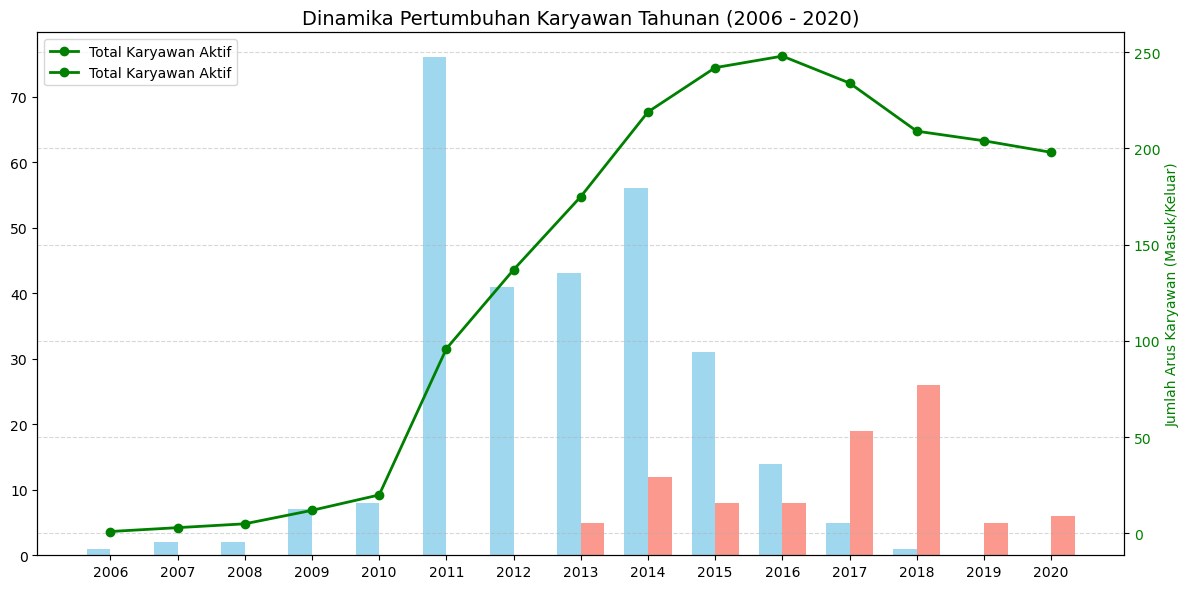

In [20]:
plt.figure(figsize=(12, 6))

# Plot Bar untuk Arus Keluar-Masuk (Flow)
width = 0.35
plt.bar(annual_report['Year'] - width/2, annual_report['Joined'], width=width, label='Karyawan Masuk (Joined)', color='skyblue', alpha=0.8)
plt.bar(annual_report['Year'] + width/2, annual_report['Resigned'], width=width, label='Karyawan Keluar (Resigned)', color='salmon', alpha=0.8)

# Plot Garis untuk Total Karyawan (Stock)
# Menggunakan sumbu Y kedua (twinx) agar skala terlihat jelas jika perbedaannya besar
ax2 = plt.gca().twinx()
ax2.plot(annual_report['Year'], annual_report['Total_Employees'], color='green', marker='o', linewidth=2, label='Total Karyawan Aktif')
ax2.set_ylabel('Total Karyawan Aktif', color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Labeling & Styling
plt.title('Dinamika Pertumbuhan Karyawan Tahunan (2006 - 2020)', fontsize=14)
plt.xlabel('Tahun')
plt.ylabel('Jumlah Arus Karyawan (Masuk/Keluar)')
plt.xticks(annual_report['Year'], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Menggabungkan Legend dari kedua axis
lines, labels = plt.gca().get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
plt.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()

## Resign Reason Analysis

### DEEP CLEANING & IMPUTATION

In [21]:
df['AlasanResign'] = df['AlasanResign'].fillna('masih_bekerja') # Handle NaN standard
df['AlasanResign'] = df['AlasanResign'].replace(r'^\s*$', 'masih_bekerja', regex=True) # Handle spasi/string kosong
df['AlasanResign'] = df['AlasanResign'].astype(str).str.lower()

### AGREGASI DATA

In [22]:
# Existing: Benar-benar yang statusnya 'masih_bekerja'
df_existing = df[df['AlasanResign'] == 'masih_bekerja']
agg_existing = df_existing.groupby('Pekerjaan')['EnterpriseID'].count().reset_index(name='Existing_Count')

# Resigned: Yang statusnya BUKAN 'masih_bekerja'
df_resigned = df[df['AlasanResign'] != 'masih_bekerja']
agg_resigned = df_resigned.groupby('Pekerjaan')['EnterpriseID'].count().reset_index(name='Resigned_Count')

In [23]:
agg_existing

,Pekerjaan,Existing_Count
0,Data Analyst,8
1,Data Engineer,7
2,DevOps Engineer,3
3,Digital Product Manager,2
4,Machine Learning Engineer,2
5,Product Design (UI & UX),15
6,Product Design (UX Researcher),1
7,Product Manager,11
8,Scrum Master,3
9,Software Architect,1


In [24]:
agg_resigned

,Pekerjaan,Resigned_Count
0,Data Analyst,8
1,Data Engineer,3
2,Product Design (UI & UX),9
3,Product Manager,6
4,Software Engineer (Android),7
5,Software Engineer (Back End),28
6,Software Engineer (Front End),28


### Menggabungkan DataFrame (Outer Join)

In [25]:
division_stats = pd.merge(agg_existing, agg_resigned, on='Pekerjaan', how='outer')
division_stats = division_stats.fillna(0)

In [26]:
division_stats

,Pekerjaan,Existing_Count,Resigned_Count
0,Data Analyst,8,8.0
1,Data Engineer,7,3.0
2,DevOps Engineer,3,0.0
3,Digital Product Manager,2,0.0
4,Machine Learning Engineer,2,0.0
5,Product Design (UI & UX),15,9.0
6,Product Design (UX Researcher),1,0.0
7,Product Manager,11,6.0
8,Scrum Master,3,0.0
9,Software Architect,1,0.0


### Menghitung Total Employee & Persentase Retention

In [27]:
division_stats['Total_Employee'] = division_stats['Existing_Count'] + division_stats['Resigned_Count']
division_stats['Retention_Rate'] = (division_stats['Existing_Count'] / division_stats['Total_Employee']) * 100

# Urutkan dari Retention Terendah
division_stats = division_stats.sort_values('Retention_Rate', ascending=True).reset_index(drop=True)

# Tampilkan Hasil Validasi
print("--- Divisi Paling Rentan (Top 5 Lowest Retention) ---")
print(division_stats[['Pekerjaan', 'Total_Employee', 'Retention_Rate']].head())

--- Divisi Paling Rentan (Top 5 Lowest Retention) ---
                       Pekerjaan  Total_Employee  Retention_Rate
0                   Data Analyst            16.0       50.000000
1  Software Engineer (Front End)            72.0       61.111111
2       Product Design (UI & UX)            24.0       62.500000
3                Product Manager            17.0       64.705882
4                  Data Engineer            10.0       70.000000


### Plot Persentase Employee yang Masih Ada (Retention Rate)

C:\Users\user\AppData\Local\Temp\ipykernel_472\2126596014.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Retention_Rate', y='Pekerjaan', data=division_stats, palette='RdYlGn')


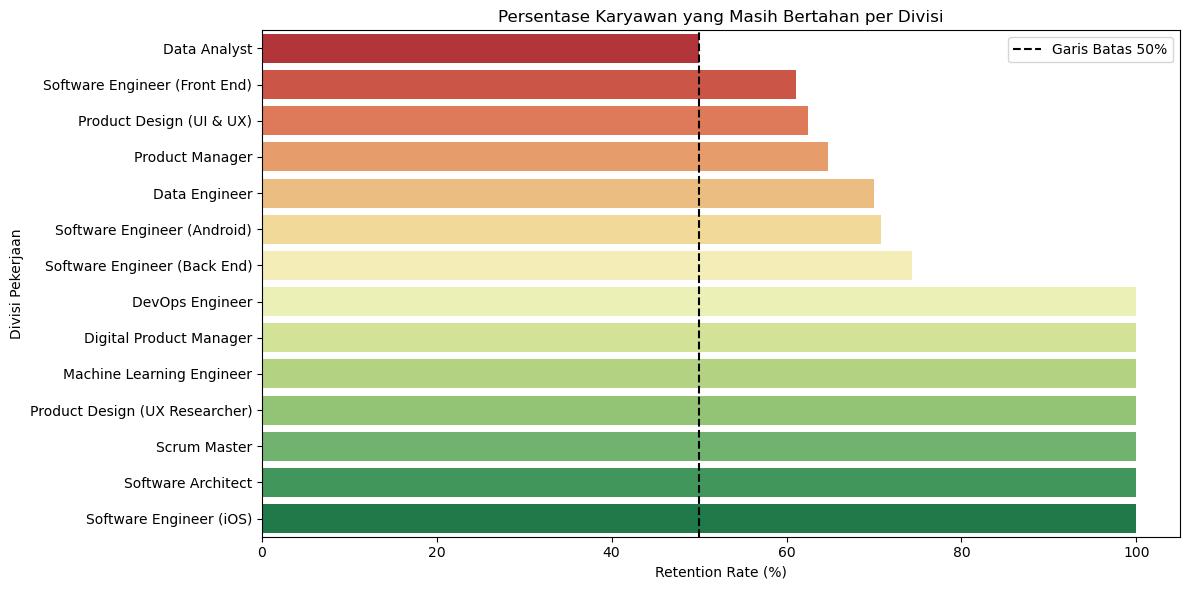

In [28]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Retention_Rate', y='Pekerjaan', data=division_stats, palette='RdYlGn')
plt.title('Persentase Karyawan yang Masih Bertahan per Divisi')
plt.xlabel('Retention Rate (%)')
plt.ylabel('Divisi Pekerjaan')
plt.axvline(x=50, color='k', linestyle='--', label='Garis Batas 50%')
plt.legend()
plt.tight_layout()
plt.show()

### Deep Dive: Analisis Divisi Paling Rentan

In [29]:
worst_division = division_stats.iloc[0]['Pekerjaan']
print(f"\nDivisi dengan tingkat resign tertinggi (Valid): {worst_division}")

# Filter data Deep Dive
worst_div_data = df[(df['Pekerjaan'] == worst_division) & (df['AlasanResign'] != 'masih_bekerja')]

# Agregasi Faktor Penyebab
agg_career = worst_div_data['JenjangKarir'].value_counts().reset_index()
agg_career.columns = ['JenjangKarir', 'Count']

agg_perf = worst_div_data['PerformancePegawai'].value_counts().reset_index()
agg_perf.columns = ['PerformancePegawai', 'Count']

agg_reason = worst_div_data['AlasanResign'].value_counts().reset_index()
agg_reason.columns = ['AlasanResign', 'Count']


Divisi dengan tingkat resign tertinggi (Valid): Data Analyst


### Plot Agregasi Deep Dive

C:\Users\user\AppData\Local\Temp\ipykernel_472\220676557.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x='JenjangKarir', y='Count', data=agg_career, palette='viridis')
C:\Users\user\AppData\Local\Temp\ipykernel_472\220676557.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='PerformancePegawai', y='Count', data=agg_perf, palette='magma')
C:\Users\user\AppData\Local\Temp\ipykernel_472\220676557.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[2], x='Count', y='AlasanResign', data=agg_reason, palet

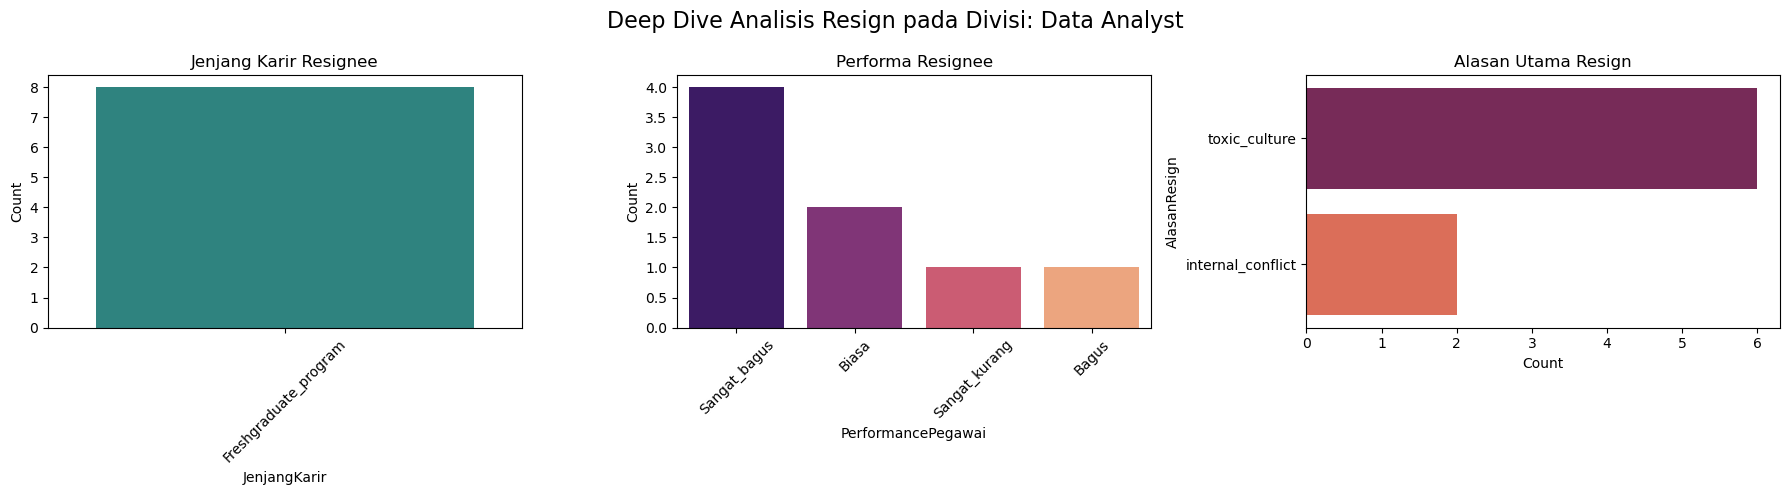

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Deep Dive Analisis Resign pada Divisi: {worst_division}', fontsize=16)

sns.barplot(ax=axes[0], x='JenjangKarir', y='Count', data=agg_career, palette='viridis')
axes[0].set_title('Jenjang Karir Resignee')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(ax=axes[1], x='PerformancePegawai', y='Count', data=agg_perf, palette='magma')
axes[1].set_title('Performa Resignee')
axes[1].tick_params(axis='x', rotation=45)

sns.barplot(ax=axes[2], x='Count', y='AlasanResign', data=agg_reason, palette='rocket')
axes[2].set_title('Alasan Utama Resign')

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

## Build some Machine learning

C:\Users\user\AppData\Local\Temp\ipykernel_472\2878367220.py:50: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['PernahBekerja'] = df['PernahBekerja'].replace(mapping_biner)


Proporsi Target Training Awal:
IsResign
0    0.688372
1    0.311628
Name: proportion, dtype: float64
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best Hyperparameters: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 50, 'classifier__scale_pos_weight': 2}

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.50      0.04      0.07        50
           1       0.29      0.91      0.44        22

    accuracy                           0.31        72
   macro avg       0.40      0.47      0.26        72
weighted avg       0.44      0.31      0.19        72



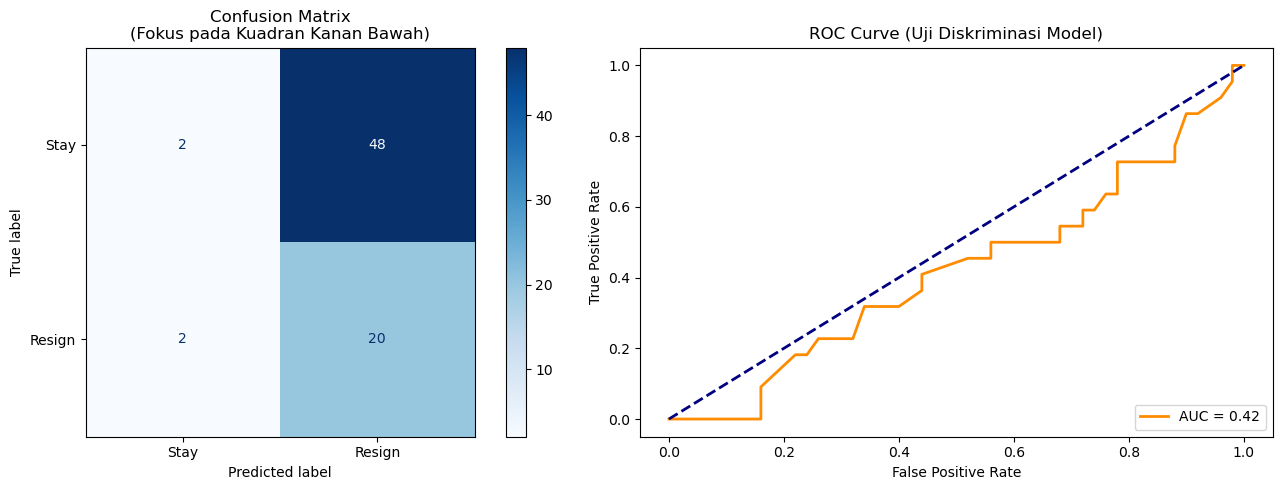

C:\Users\user\AppData\Local\Temp\ipykernel_472\2878367220.py:170: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp.head(10), palette='mako')


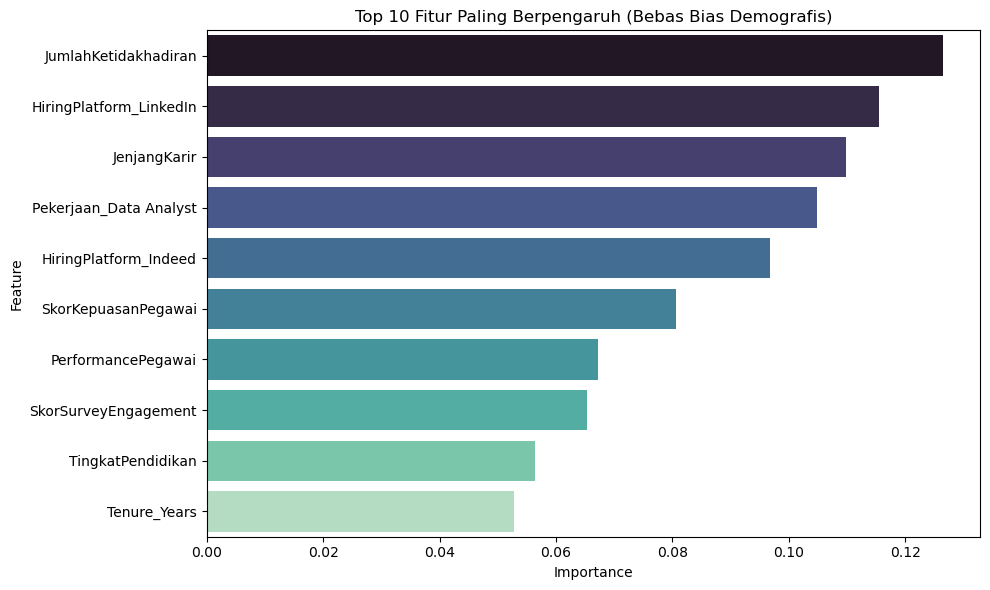

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Preprocessing & ML Tools
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay

# ==============================================================================
# 1. DATA PREPROCESSING & FEATURE ENGINEERING
# ==============================================================================
# Load data
df = pd.read_excel('Improving Employee Retention by Predicting Employee Attrition Using Machine Learning.xlsx')

# Handle AlasanResign (Target Variable Definition)
df['AlasanResign'] = df['AlasanResign'].fillna('masih_bekerja')
df['AlasanResign'] = df['AlasanResign'].replace(r'^\s*$', 'masih_bekerja', regex=True)
df['AlasanResign'] = df['AlasanResign'].astype(str).str.lower()

# Buat Target: 1 jika Resign, 0 jika Stay
df['IsResign'] = np.where(df['AlasanResign'] != 'masih_bekerja', 1, 0)

# Feature Engineering: Menghitung Masa Kerja (Tenure) dalam tahun
df['TanggalHiring'] = pd.to_datetime(df['TanggalHiring'], errors='coerce')
# Asumsi waktu analisis adalah akhir dari data (misal: 1 Jan 2021)
reference_date = pd.to_datetime('2021-01-01') 
df['Tenure_Years'] = (reference_date - df['TanggalHiring']).dt.days / 365.25
df['Tenure_Years'] = df['Tenure_Years'].fillna(df['Tenure_Years'].median()) # Imputasi jika ada yang kosong

# Handle Nulls pada fitur numerik
num_cols_to_fill = ['SkorKepuasanPegawai', 'JumlahKeikutsertaanProjek', 'JumlahKeterlambatanSebulanTerakhir', 'JumlahKetidakhadiran', 'IkutProgramLOP']
for col in num_cols_to_fill:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0) 
mapping_biner = {'yes': 1, 'no': 0, 'Ya': 1, 'Tidak': 0, '1': 1, '0': 0}
if 'PernahBekerja' in df.columns:
    df['PernahBekerja'] = df['PernahBekerja'].replace(mapping_biner)
    df['PernahBekerja'] = pd.to_numeric(df['PernahBekerja'], errors='coerce').fillna(0)

if 'IkutProgramLOP' in df.columns:
    df['IkutProgramLOP'] = df['IkutProgramLOP'].replace(mapping_biner)
    df['IkutProgramLOP'] = pd.to_numeric(df['IkutProgramLOP'], errors='coerce').fillna(0)

# Feature Selection: Membuang fitur bias, PII (Personal Info), dan Data Leakage
cols_to_drop = [
    # PII & Unused
    'Username', 'EnterpriseID', 'NomorHP', 'Email', 
    # Mencegah Bias (Anti-Discriminative Policy)
    'JenisKelamin', 'StatusPernikahan', 'AsalDaerah', 'TanggalLahir',
    # Data Leakage (Fitur masa depan)
    'AlasanResign', 'TanggalResign', 'TanggalPenilaianKaryawan', 'TanggalHiring'
]
df_ml = df.drop(columns=cols_to_drop)

# Definisikan kolom kategorikal dan numerikal untuk ColumnTransformer
cat_nominal = ['StatusKepegawaian', 'Pekerjaan', 'HiringPlatform']
cat_ordinal = ['JenjangKarir', 'PerformancePegawai', 'TingkatPendidikan']
num_features = [col for col in df_ml.columns if col not in cat_nominal + cat_ordinal + ['IsResign']]

# Pisahkan Features (X) dan Target (y)
X = df_ml.drop(columns=['IsResign'])
y = df_ml['IsResign']

# ==============================================================================
# 2. DATA SPLIT & MENGATASI IMBALANCED DATA (SMOTE)
# ==============================================================================
# Stratify memastikan rasio target di train dan test sama
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print(f"Proporsi Target Training Awal:\n{y_train.value_counts(normalize=True)}")

# Preprocessor Pipeline
# Ordinal mapping menyesuaikan hierarki dunia nyata
ordinal_mapping = [
    ['Freshgraduate_program', 'Mid_level', 'Senior_level'], # JenjangKarir
    ['Sangat_kurang', 'Kurang', 'Biasa', 'Bagus', 'Sangat_bagus'], # Performance
    ['SMA', 'Sarjana', 'Magister', 'Doktor'] # Pendidikan (Sesuaikan jika ada label lain)
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat_nom', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_nominal),
        ('cat_ord', OrdinalEncoder(categories=ordinal_mapping, handle_unknown='use_encoded_value', unknown_value=-1), cat_ordinal)
    ]
)

# ==============================================================================
# 3 & 4. MODEL SELECTION, PIPELINE, & HYPERPARAMETER TUNING
# ==============================================================================
# Kita menggunakan ImbPipeline agar SMOTE hanya diaplikasikan pada fold training saat Cross-Validation
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)), # Mengatasi imbalanced class
    ('classifier', XGBClassifier(random_state=42, eval_metric='logloss')) # XGBoost umumnya sangat baik untuk data tabular
])

# Hyperparameter grid untuk XGBoost
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [3, 5],
    'classifier__learning_rate': [0.01, 0.1],
    'classifier__scale_pos_weight': [1, 2] # Ekstra pembobotan untuk kelas minoritas
}

# CV menggunakan StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Menggunakan Scoring 'recall' karena tujuan bisnis adalah Early Prevention.
# Kita lebih memilih model "terlalu sensitif" (False Positive) daripada kebobolan karyawan potensial (False Negative).
grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='recall', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"\nBest Hyperparameters: {grid_search.best_params_}")

# ==============================================================================
# 5. EVALUASI DAN VISUALISASI METRICS
# ==============================================================================
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay', 'Resign'])
disp.plot(cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix\n(Fokus pada Kuadran Kanan Bawah)')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f'AUC = {auc:.2f}', color='darkorange', lw=2)
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (Uji Diskriminasi Model)')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# Pengecekan Fitur Penting (Transparansi Model)
# Mengambil nama fitur setelah OneHotEncoding
cat_nom_features = best_model.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(cat_nominal)
all_feature_names = num_features + list(cat_nom_features) + cat_ordinal

importances = best_model.named_steps['classifier'].feature_importances_
feat_imp = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(10), palette='mako')
plt.title('Top 10 Fitur Paling Berpengaruh (Bebas Bias Demografis)')
plt.tight_layout()
plt.show()

## Explainable AI

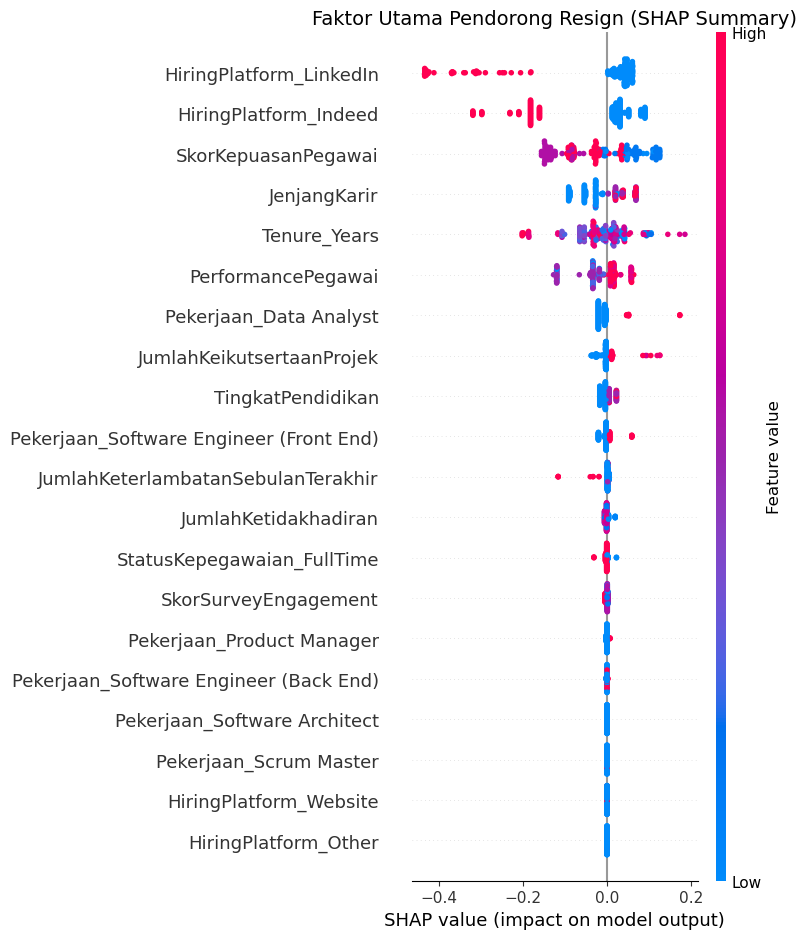

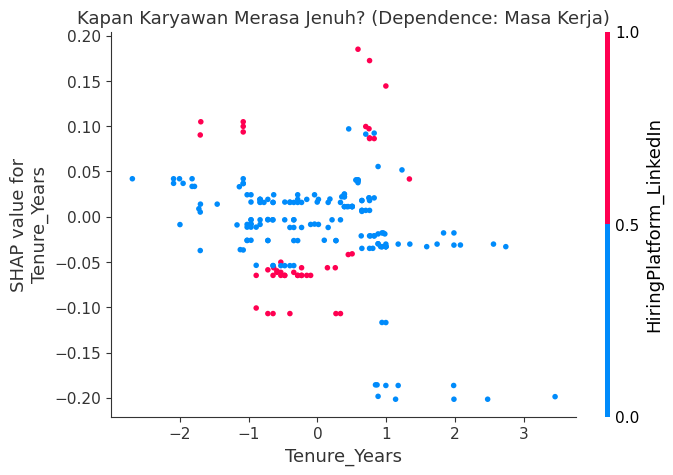

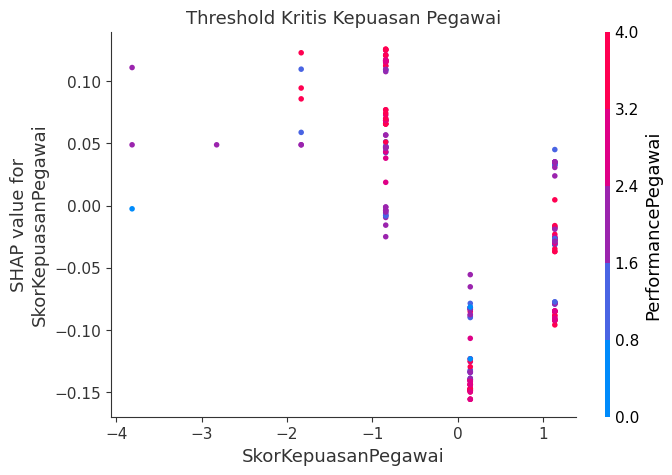

In [33]:
import shap
import numpy as np

# Asumsi 'best_model' adalah model XGBoost/RandomForest Anda dari pipeline sebelumnya,
# dan 'X_train' sudah melalui tahap preprocessor (OneHotEncoding & Scaling).
# Kita ekstrak model classifier dari pipeline
classifier_model = best_model.named_steps['classifier']
X_train_transformed = best_model.named_steps['preprocessor'].transform(X_train)

# Dapatkan nama fitur yang sebenarnya setelah di-transform
cat_nom_features = best_model.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(cat_nominal)
all_feature_names = num_features + list(cat_nom_features) + cat_ordinal

# Inisialisasi SHAP Explainer
explainer = shap.TreeExplainer(classifier_model)
shap_values = explainer.shap_values(X_train_transformed)

# 1. SHAP SUMMARY PLOT (Melihat Gambaran Besar)
plt.figure(figsize=(10, 8))
plt.title("Faktor Utama Pendorong Resign (SHAP Summary)", fontsize=14)
# Gunakan shap_values (untuk XGBoost) atau shap_values[1] (untuk Random Forest kelas target 1)
shap.summary_plot(shap_values, X_train_transformed, feature_names=all_feature_names, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png')
plt.show()

# 2. SHAP DEPENDENCE PLOT (Mencari Threshold / Batas Kritis)
# Contoh menganalisis Masa Kerja (Tenure)
feature_idx_tenure = all_feature_names.index('Tenure_Years')
shap.dependence_plot(
    ind=feature_idx_tenure, 
    shap_values=shap_values, 
    features=X_train_transformed, 
    feature_names=all_feature_names,
    title="Kapan Karyawan Merasa Jenuh? (Dependence: Masa Kerja)"
)

# Contoh menganalisis Skor Kepuasan
feature_idx_skor = all_feature_names.index('SkorKepuasanPegawai')
shap.dependence_plot(
    ind=feature_idx_skor, 
    shap_values=shap_values, 
    features=X_train_transformed, 
    feature_names=all_feature_names,
    title="Threshold Kritis Kepuasan Pegawai"
)